In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_ef_AC_stark_vals=[np.float64(0.6225948637445211), np.float64(0.6334656814566403), np.float64(0.6230882765524478), np.float64(0.5994626490319437), np.float64(0.5765887988951279), np.float64(0.5554667261420007), np.float64(0.5310964307725617), np.float64(0.5044779127868111), np.float64(0.4786111721847489), np.float64(0.451496208966375), np.float64(0.42313302313168943), np.float64(0.39252161468069235), np.float64(0.36066198361338364), np.float64(0.3265541299297633), np.float64(0.2931980536298313), np.float64(0.25559375471358753), np.float64(0.2197412331810324), np.float64(0.19164048903216546), np.float64(0.14429152226698688), np.float64(0.10769433288549693)]

list_AC_stark_vals=[np.float64(-0.06854670085959402), np.float64(-0.08153707558259009), np.float64(-0.09579972281290855), np.float64(-0.1112346425505495), np.float64(-0.12794183479551288), np.float64(-0.1459212995477987), np.float64(-0.165373036807407), np.float64(-0.18579704657433777), np.float64(-0.20819332884859085), np.float64(-0.23176188363016656), np.float64(-0.25670271091906466), np.float64(-0.28311581071528513), np.float64(-0.3106011830188282), np.float64(-0.3400588278296935), np.float64(-0.37078874514788146), np.float64(-0.4024909349733919), np.float64(-0.43426539730622454), np.float64(-0.4636121321463798), np.float64(-0.5065311394938574), np.float64(-0.5382224193486578)]
list_AC_stark_vals=[np.float64(-0.06864670085959403), np.float64(-0.0827370755825901), np.float64(-0.09829972281290855), np.float64(-0.11533464255054951), np.float64(-0.1339418347955129), np.float64(-0.1542212995477987), np.float64(-0.176173036807407), np.float64(-0.19989704657433777), np.float64(-0.22549332884859086), np.float64(-0.2529618836301666), np.float64(-0.28280271091906467), np.float64(-0.31211581071528516), np.float64(-0.33960118301882825), np.float64(-0.3865588278296935), np.float64(-0.42728874514788145), np.float64(-0.4745909349733919), np.float64(-0.5389), np.float64(-0.5881121321463798), np.float64(-0.6631311394938575), np.float64(-0.6822224193486578)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=10,drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, max_f_vals)
    plt.xlabel("delta=ω_supp-ω_ef/3 (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmin(max_f_vals)
    delta=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

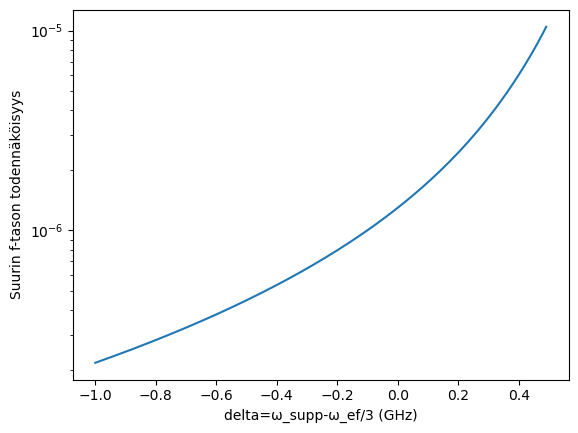

Amplitudi (GHz): 5.862378319584177
AC-stark siirtymä (GHz): -1.0
E-tason suurin todennäköisyys: 0.9998351130418028
F-tason suurin todennäköisyys: 3.5174558496601136e-07
Pulssin pituus (ns): 251.1213313093993
Rabi-taajuus (fourier):  0.0021851671925211145


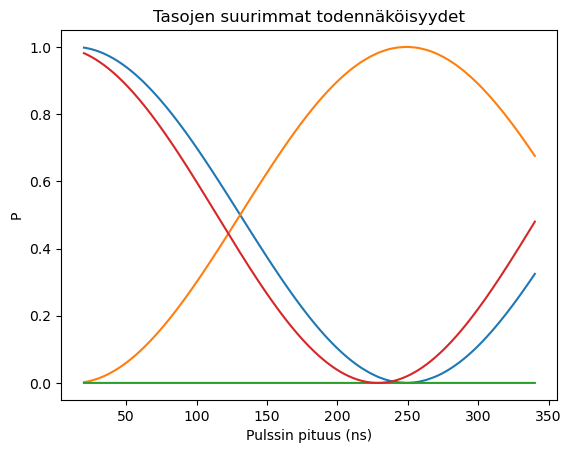

---------------------------------------------


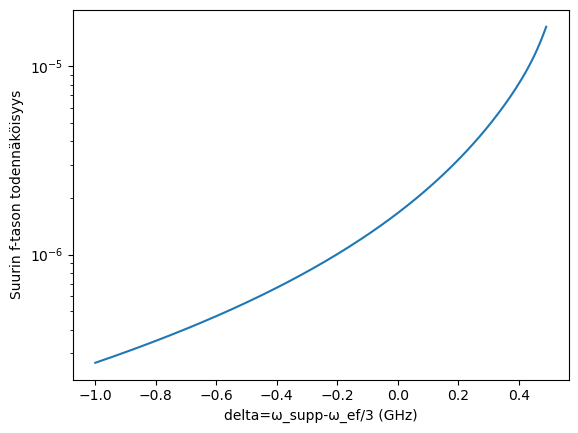

Amplitudi (GHz): 6.425810560825677
AC-stark siirtymä (GHz): -1.0
E-tason suurin todennäköisyys: 0.9998454868211525
F-tason suurin todennäköisyys: 3.6814163064525614e-07
Pulssin pituus (ns): 191.76429658969244
Rabi-taajuus (fourier):  0.0026510478848871867


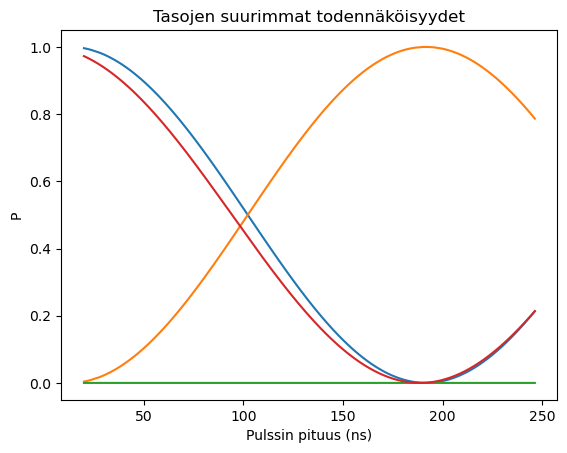

---------------------------------------------


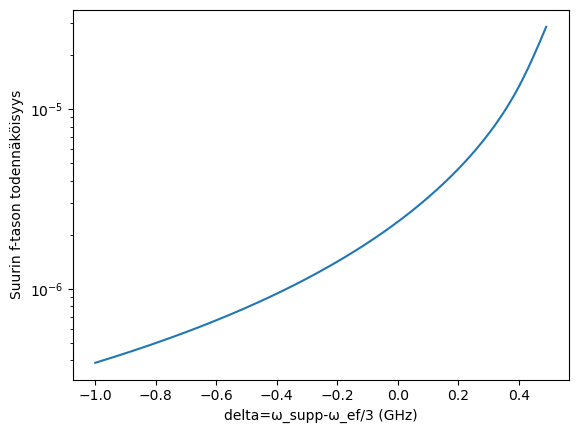

Amplitudi (GHz): 6.989242802067177
AC-stark siirtymä (GHz): -1.0
E-tason suurin todennäköisyys: 0.9996447708941135
F-tason suurin todennäköisyys: 4.3630439997670075e-07
Pulssin pituus (ns): 154.67334161952056
Rabi-taajuus (fourier):  0.0035229224357121126


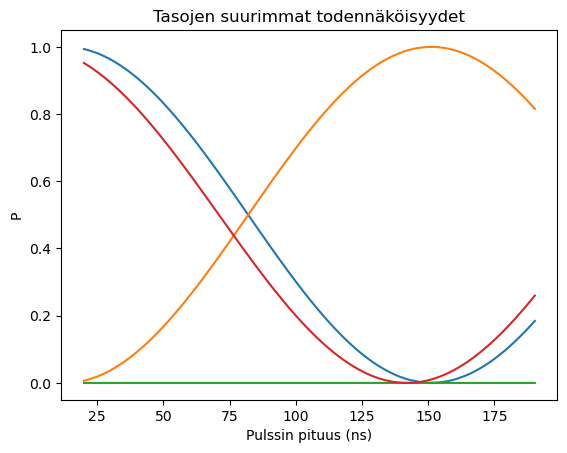

---------------------------------------------


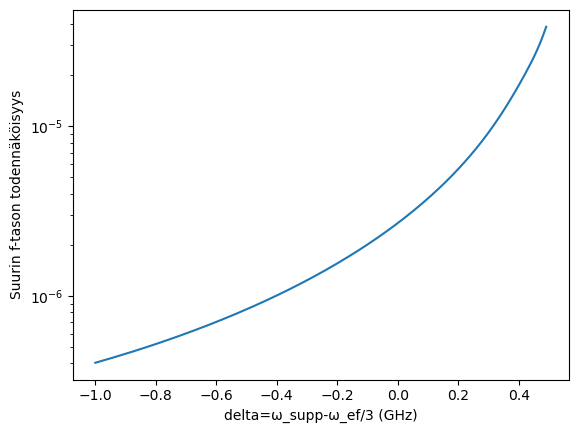

Amplitudi (GHz): 7.5526750433086765
AC-stark siirtymä (GHz): -1.0
E-tason suurin todennäköisyys: 0.9994494229175279
F-tason suurin todennäköisyys: 5.894177156974727e-07
Pulssin pituus (ns): 124.95883860130819
Rabi-taajuus (fourier):  0.0045181005089026186


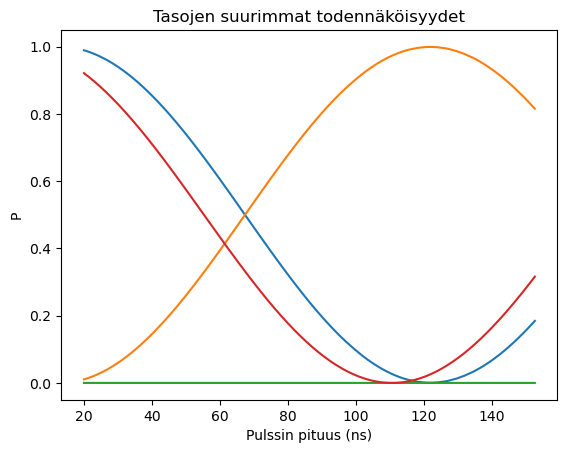

---------------------------------------------


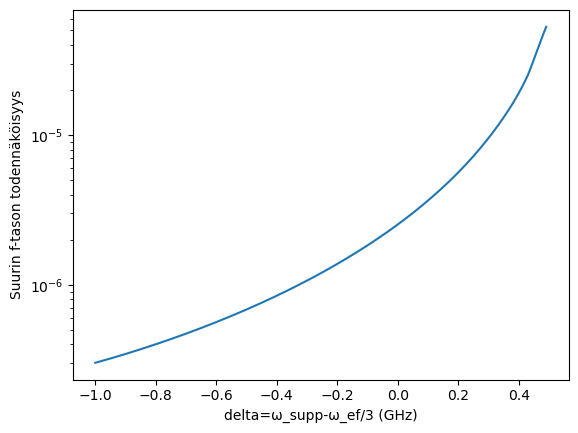

Amplitudi (GHz): 8.116107284550177
AC-stark siirtymä (GHz): -1.0
E-tason suurin todennäköisyys: 0.9990242705698982
F-tason suurin todennäköisyys: 8.073873542603575e-07
Pulssin pituus (ns): 99.64566418712425
Rabi-taajuus (fourier):  0.005665994094233032


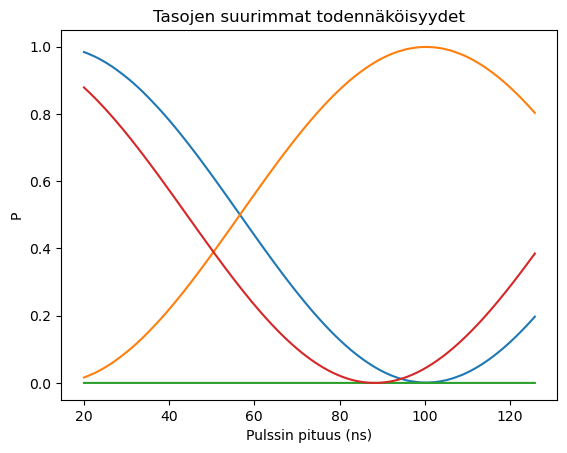

---------------------------------------------


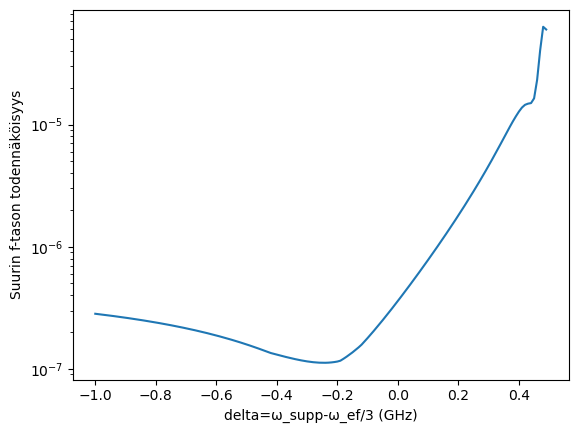

Amplitudi (GHz): 8.679539525791677
AC-stark siirtymä (GHz): -0.25
E-tason suurin todennäköisyys: 0.9994648731872078
F-tason suurin todennäköisyys: 7.330571035382499e-06
Pulssin pituus (ns): 83.26886647055576
Rabi-taajuus (fourier):  0.006996006950648593


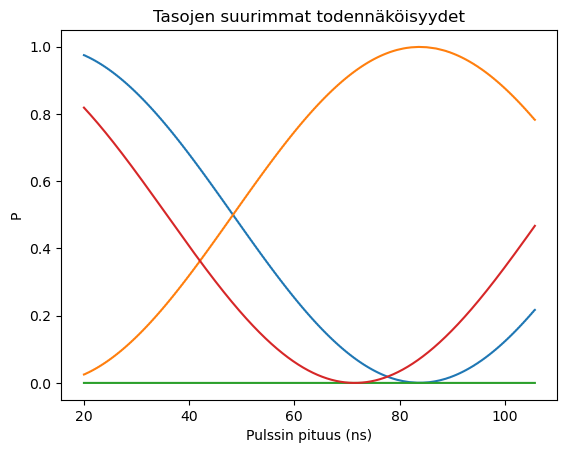

---------------------------------------------


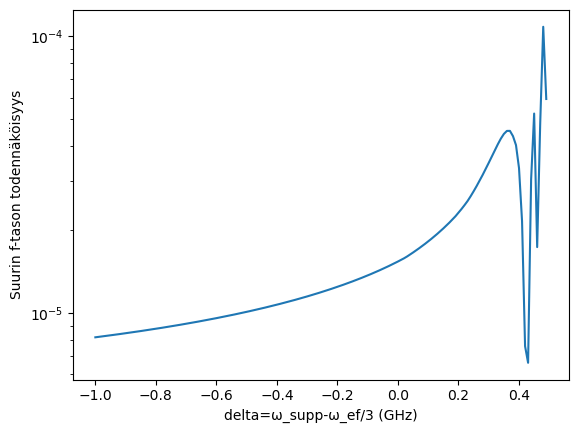

Amplitudi (GHz): 9.242971767033177
AC-stark siirtymä (GHz): 0.43
E-tason suurin todennäköisyys: 0.963097638756629
F-tason suurin todennäköisyys: 0.00016587622124953393
Pulssin pituus (ns): 81.92542028845864
Rabi-taajuus (fourier):  0.008538005426242832


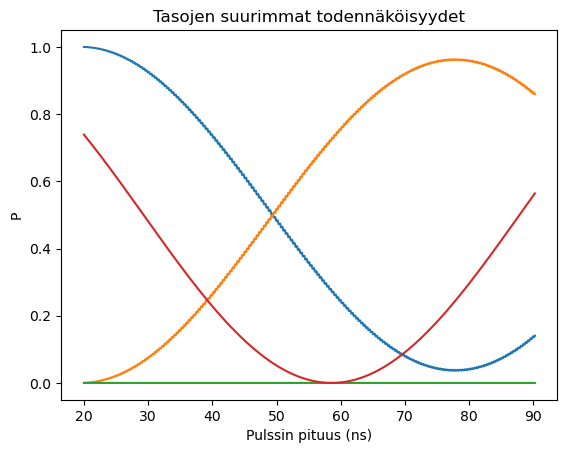

---------------------------------------------


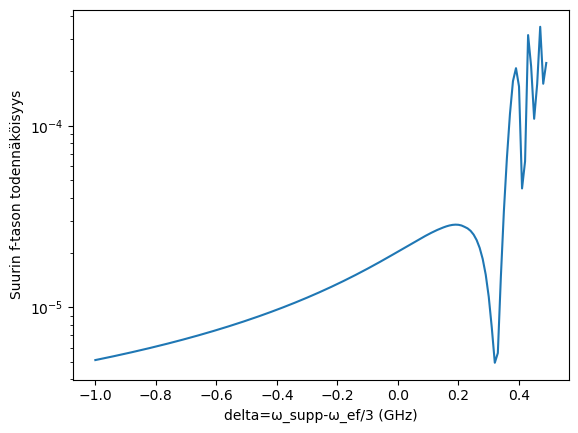

Amplitudi (GHz): 9.806404008274676
AC-stark siirtymä (GHz): 0.32
E-tason suurin todennäköisyys: 0.9783507965638583
F-tason suurin todennäköisyys: 0.00012355461271660022
Pulssin pituus (ns): 63.92615958182425
Rabi-taajuus (fourier):  0.010320982528457654


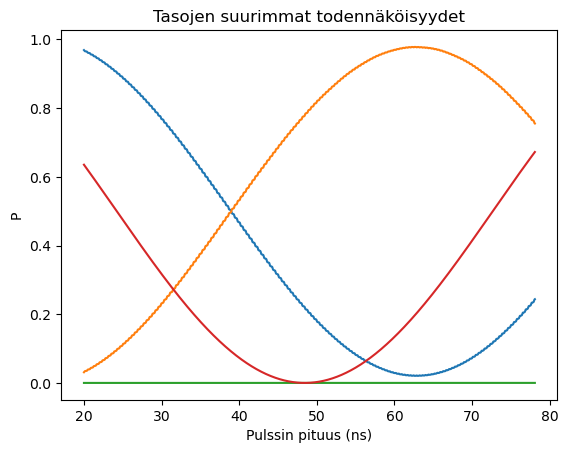

---------------------------------------------


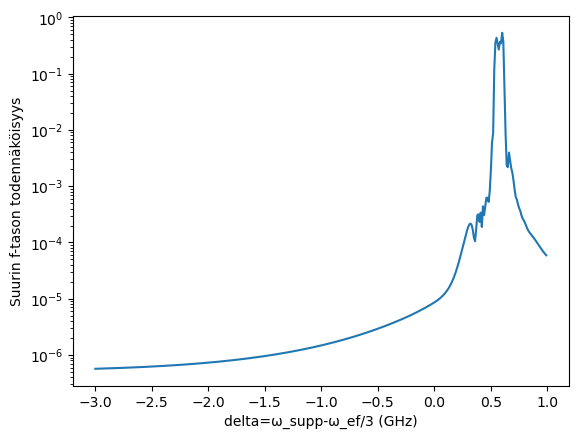

Amplitudi (GHz): 10.369836249516176
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9892485949547069
F-tason suurin todennäköisyys: 1.7977586296367277e-06
Pulssin pituus (ns): 54.18611422594333
Rabi-taajuus (fourier):  0.012374372956916003


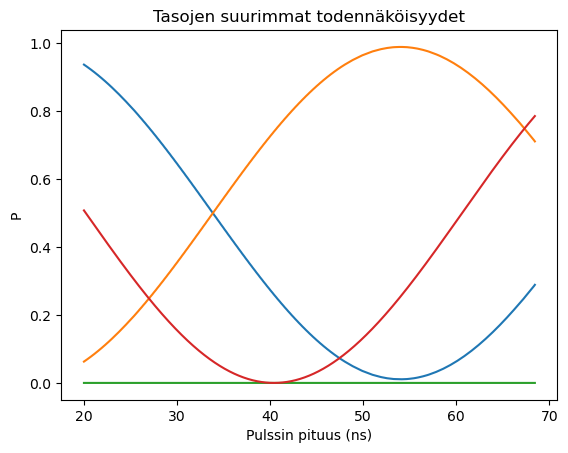

---------------------------------------------


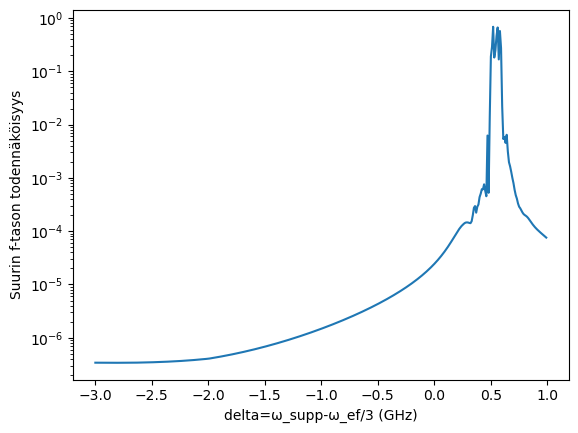

Amplitudi (GHz): 10.933268490757676
AC-stark siirtymä (GHz): -2.83
E-tason suurin todennäköisyys: 0.985512231652854
F-tason suurin todennäköisyys: 9.722053044130151e-07
Pulssin pituus (ns): 48.20224771157237
Rabi-taajuus (fourier):  0.01472862382283292


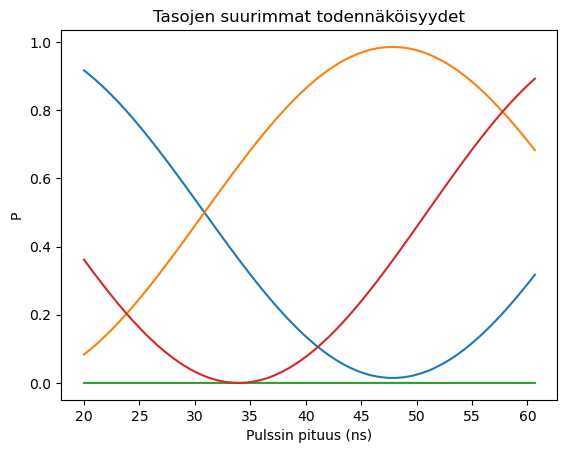

---------------------------------------------


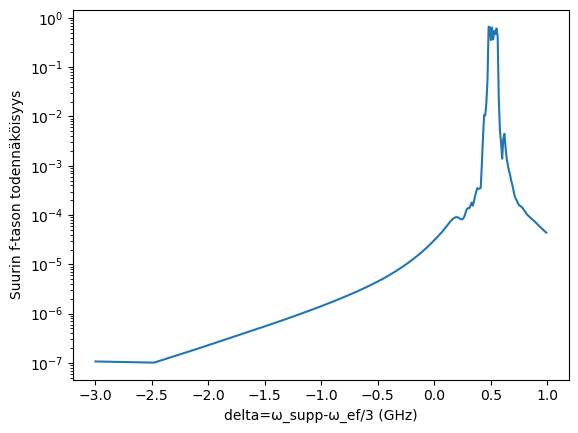

Amplitudi (GHz): 11.496700731999177
AC-stark siirtymä (GHz): -2.49
E-tason suurin todennäköisyys: 0.9780666442019711
F-tason suurin todennäköisyys: 1.318453598702175e-06
Pulssin pituus (ns): 42.949766333163765
Rabi-taajuus (fourier):  0.017411959398599963


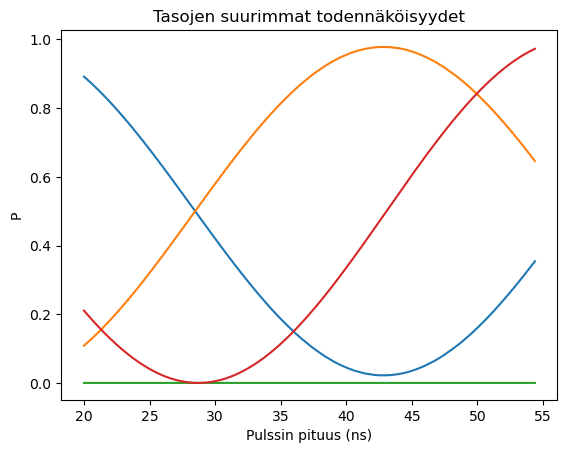

---------------------------------------------


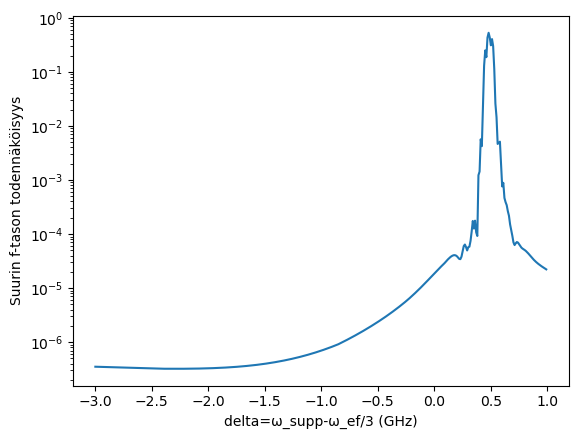

Amplitudi (GHz): 12.060132973240677
AC-stark siirtymä (GHz): -2.3
E-tason suurin todennäköisyys: 0.9876890901274917
F-tason suurin todennäköisyys: 1.3335040628774426e-06
Pulssin pituus (ns): 39.19330497546386
Rabi-taajuus (fourier):  0.020453350334258272


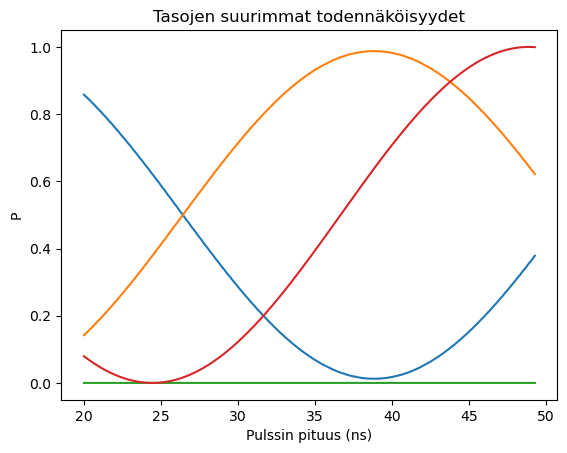

---------------------------------------------


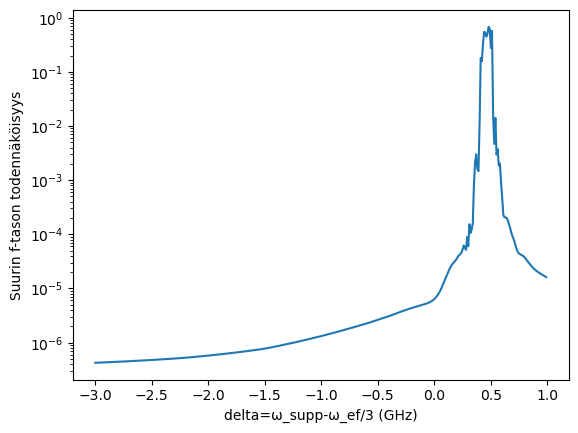

Amplitudi (GHz): 12.623565214482177
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9997795197820935
F-tason suurin todennäköisyys: 6.327039904328827e-07
Pulssin pituus (ns): 35.40638467424287
Rabi-taajuus (fourier):  0.023885245524473048


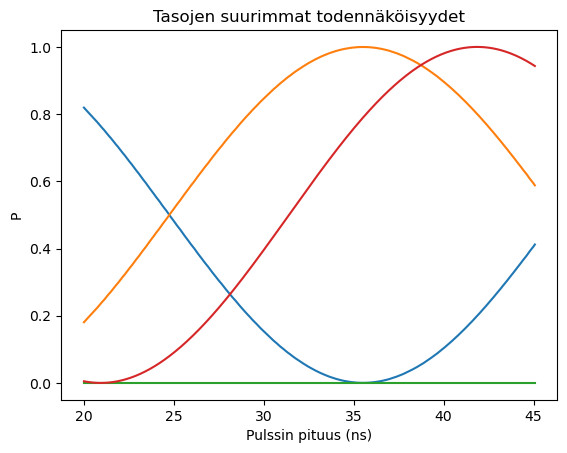

---------------------------------------------


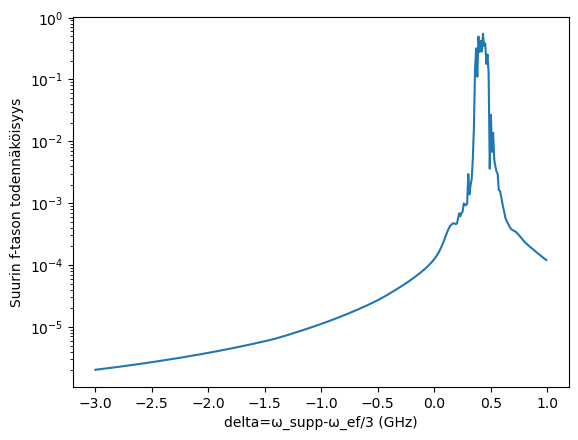

Amplitudi (GHz): 13.186997455723676
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.927342158534355
F-tason suurin todennäköisyys: 2.482627022656123e-06
Pulssin pituus (ns): 32.39647439867556
Rabi-taajuus (fourier):  0.027731915193572786


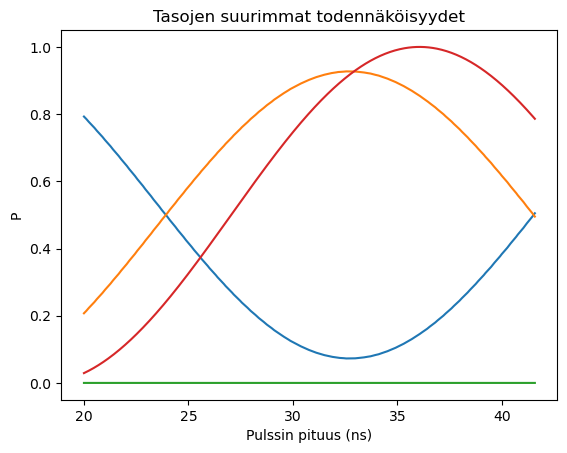

---------------------------------------------


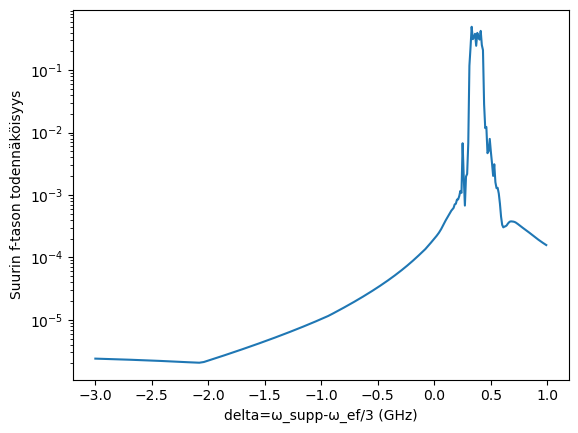

Amplitudi (GHz): 13.750429696965176
AC-stark siirtymä (GHz): -2.09
E-tason suurin todennäköisyys: 0.8958691719779852
F-tason suurin todennäköisyys: 7.714652571380997e-06
Pulssin pituus (ns): 30.1229771557598
Rabi-taajuus (fourier):  0.03203177348479736


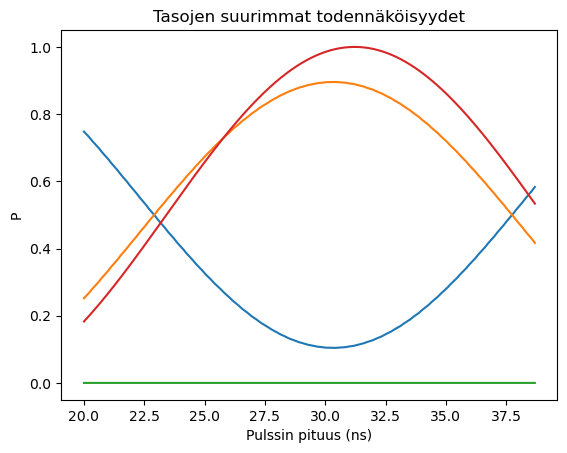

---------------------------------------------


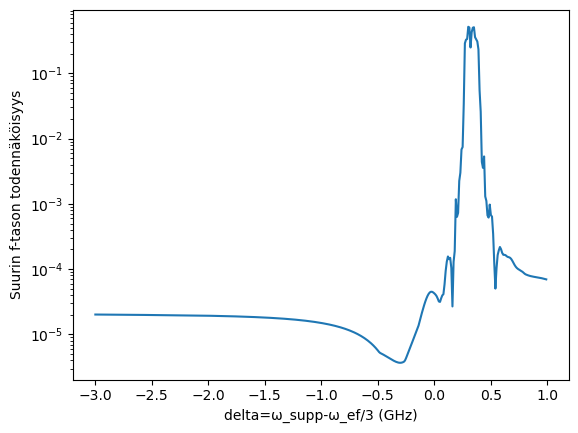

Amplitudi (GHz): 14.313861938206676
AC-stark siirtymä (GHz): -0.3
E-tason suurin todennäköisyys: 0.9160640367510838
F-tason suurin todennäköisyys: 6.027746074692167e-05
Pulssin pituus (ns): 27.83282368095483
Rabi-taajuus (fourier):  0.036800734315585025


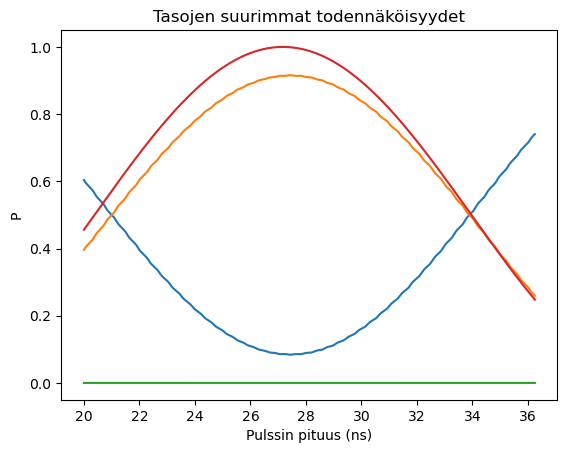

---------------------------------------------


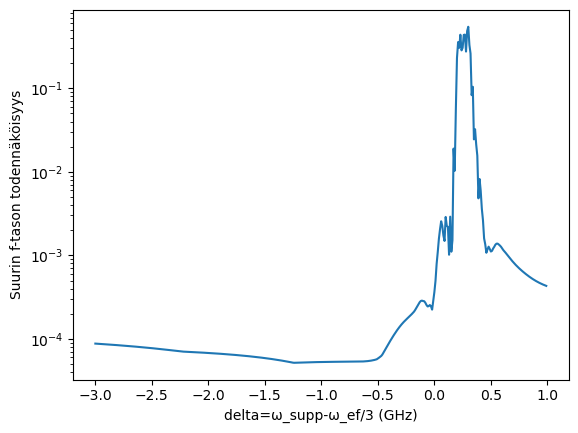

Amplitudi (GHz): 14.877294179448176
AC-stark siirtymä (GHz): -1.24
E-tason suurin todennäköisyys: 0.6176361957886409
F-tason suurin todennäköisyys: 0.00013484584376203233
Pulssin pituus (ns): 25.52728872735825
Rabi-taajuus (fourier):  0.042086193377352324


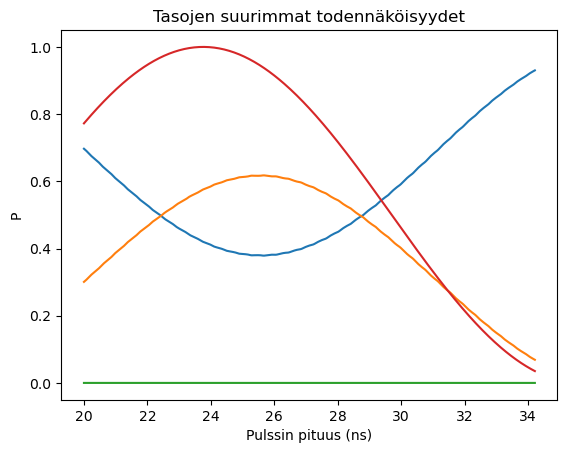

---------------------------------------------


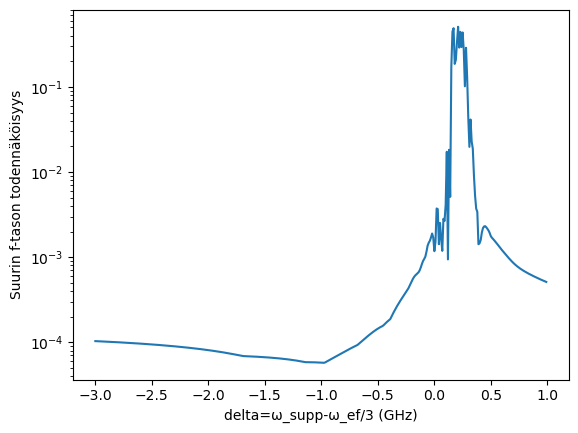

Amplitudi (GHz): 15.440726420689677
AC-stark siirtymä (GHz): -0.98
E-tason suurin todennäköisyys: 0.600612336441688
F-tason suurin todennäköisyys: 0.00013582370849895257
Pulssin pituus (ns): 23.97263222423433
Rabi-taajuus (fourier):  0.04790147852669761


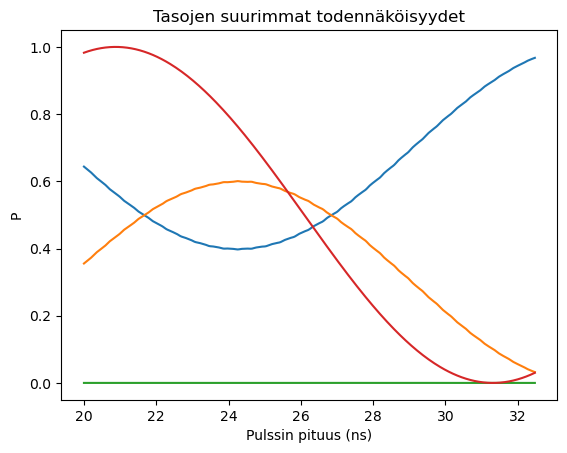

---------------------------------------------


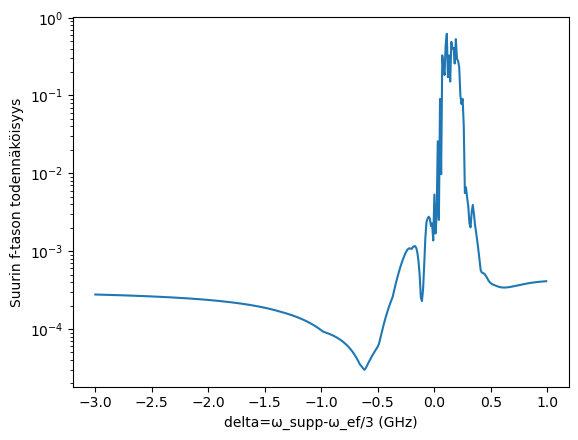

Amplitudi (GHz): 16.004158661931175
AC-stark siirtymä (GHz): -0.62
E-tason suurin todennäköisyys: 0.46589594547900065
F-tason suurin todennäköisyys: 7.188391444126075e-05
Pulssin pituus (ns): 22.406407391873223
Rabi-taajuus (fourier):  0.06332875121267867


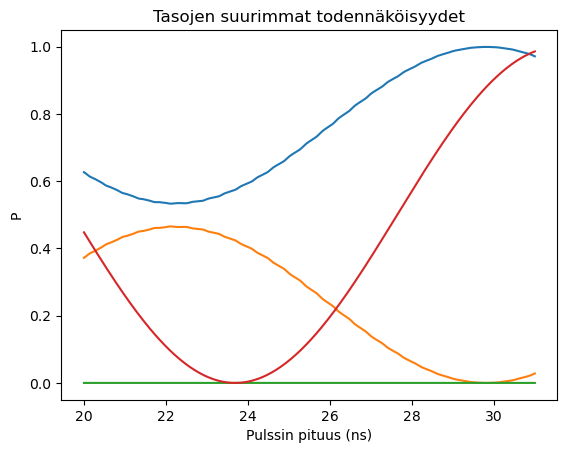

---------------------------------------------


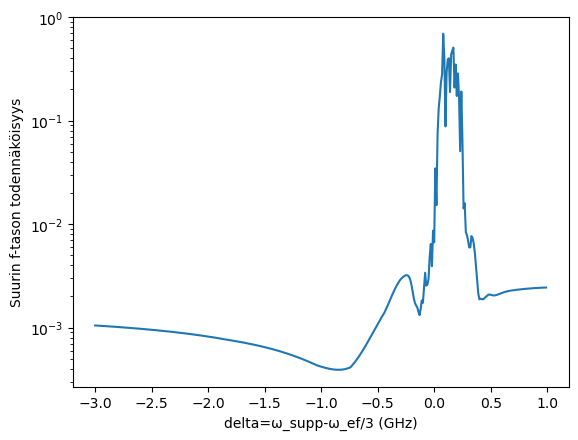

Amplitudi (GHz): 16.567590903172675
AC-stark siirtymä (GHz): -0.85
E-tason suurin todennäköisyys: 0.6365972026246767
F-tason suurin todennäköisyys: 0.0004977339249993469
Pulssin pituus (ns): 22.412286778365647
Rabi-taajuus (fourier):  0.06126272073324991


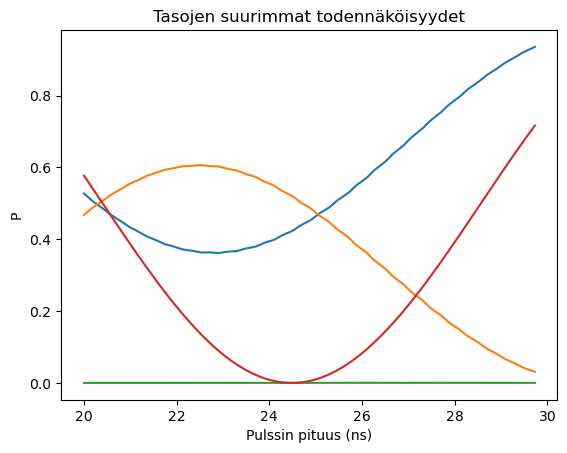

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.65
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency/3+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=0 #Arvaus AC-stark siirtymälle
    if i < 8:
        params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-100,50],100)
    else:
        params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-300,100],100)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef/3+deltas[-1],A,evolution_eigenbasis,dim,(10*f_rabi)/m,t_ramp=10,U_f=0,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])

    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319584177), np.float64(6.425810560825677), np.float64(6.989242802067177), np.float64(7.5526750433086765), np.float64(8.116107284550177), np.float64(8.679539525791677), np.float64(9.242971767033177), np.float64(9.806404008274676), np.float64(10.369836249516176), np.float64(10.933268490757676), np.float64(11.496700731999177), np.float64(12.060132973240677), np.float64(12.623565214482177), np.float64(13.186997455723676), np.float64(13.750429696965176), np.float64(14.313861938206676), np.float64(14.877294179448176), np.float64(15.440726420689677), np.float64(16.004158661931175), np.float64(16.567590903172675)]


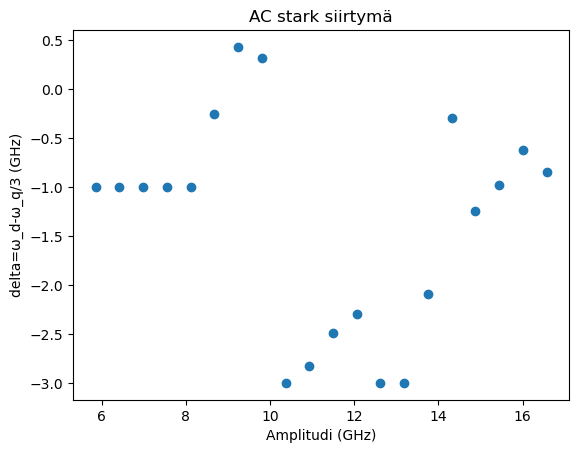

[-1.0, -1.0, -1.0, -1.0, -1.0, -0.25, 0.43, 0.32, -3.0, -2.83, -2.49, -2.3, -3.0, -3.0, -2.09, -0.3, -1.24, -0.98, -0.62, -0.85]


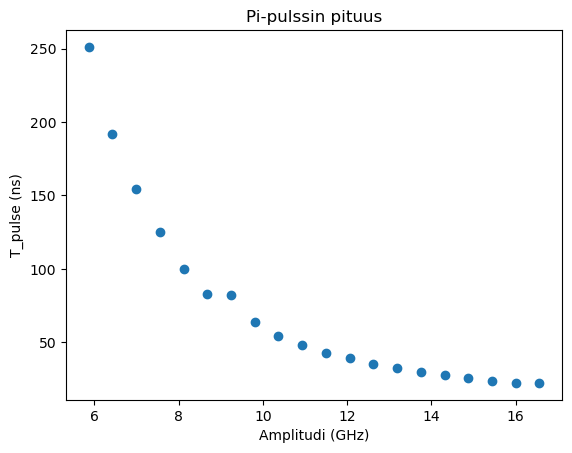

[np.float64(251.1213313093993), np.float64(191.76429658969244), np.float64(154.67334161952056), np.float64(124.95883860130819), np.float64(99.64566418712425), np.float64(83.26886647055576), np.float64(81.92542028845864), np.float64(63.92615958182425), np.float64(54.18611422594333), np.float64(48.20224771157237), np.float64(42.949766333163765), np.float64(39.19330497546386), np.float64(35.40638467424287), np.float64(32.39647439867556), np.float64(30.1229771557598), np.float64(27.83282368095483), np.float64(25.52728872735825), np.float64(23.97263222423433), np.float64(22.406407391873223), np.float64(22.412286778365647)]


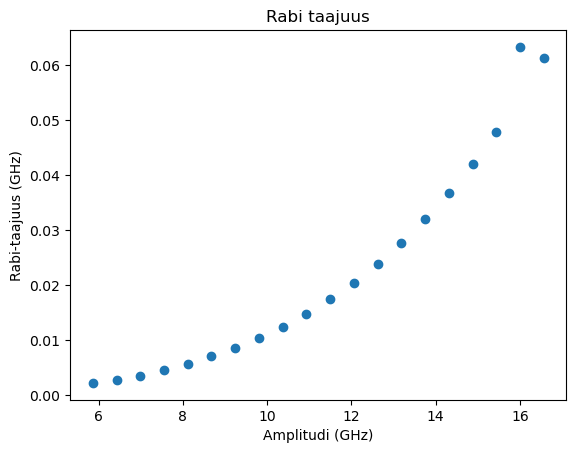

[np.float64(0.0021851671925211145), np.float64(0.0026510478848871867), np.float64(0.0035229224357121126), np.float64(0.0045181005089026186), np.float64(0.005665994094233032), np.float64(0.006996006950648593), np.float64(0.008538005426242832), np.float64(0.010320982528457654), np.float64(0.012374372956916003), np.float64(0.01472862382283292), np.float64(0.017411959398599963), np.float64(0.020453350334258272), np.float64(0.023885245524473048), np.float64(0.027731915193572786), np.float64(0.03203177348479736), np.float64(0.036800734315585025), np.float64(0.042086193377352324), np.float64(0.04790147852669761), np.float64(0.06332875121267867), np.float64(0.06126272073324991)]


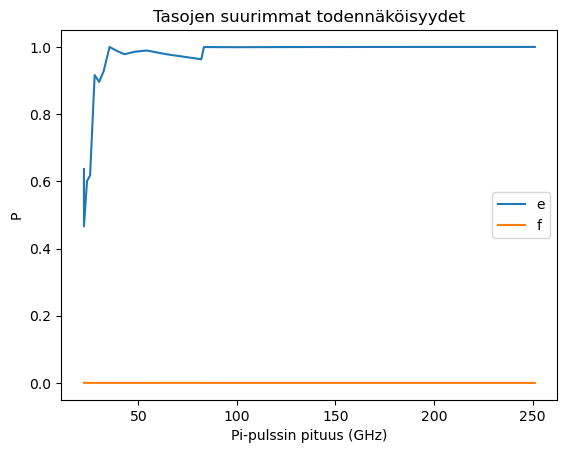

[np.float64(0.9998351130418028), np.float64(0.9998454868211525), np.float64(0.9996447708941135), np.float64(0.9994494229175279), np.float64(0.9990242705698982), np.float64(0.9994648731872078), np.float64(0.963097638756629), np.float64(0.9783507965638583), np.float64(0.9892485949547069), np.float64(0.985512231652854), np.float64(0.9780666442019711), np.float64(0.9876890901274917), np.float64(0.9997795197820935), np.float64(0.927342158534355), np.float64(0.8958691719779852), np.float64(0.9160640367510838), np.float64(0.6176361957886409), np.float64(0.600612336441688), np.float64(0.46589594547900065), np.float64(0.6365972026246767)]
[np.float64(3.5174558496601136e-07), np.float64(3.6814163064525614e-07), np.float64(4.3630439997670075e-07), np.float64(5.894177156974727e-07), np.float64(8.073873542603575e-07), np.float64(7.330571035382499e-06), np.float64(0.00016587622124953393), np.float64(0.00012355461271660022), np.float64(1.7977586296367277e-06), np.float64(9.722053044130151e-07), np.fl

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)